<a href="https://www.kaggle.com/code/marouanemourad/masked-face-super-resolution?scriptVersionId=321875343" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import tensorflow as tf
import os
import glob
from tensorflow.keras import layers, Model

import keras 
# from keras import layers
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import re
from keras.preprocessing.image import img_to_array

2026-05-28 16:44:22.159100: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779986662.392581      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779986662.469003      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779986662.987583      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986662.987645      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779986662.987648      23 computation_placer.cc:177] computation placer alr

##  env check

In [3]:
# List all physical GPU devices detected by TensorFlow
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print(gpus)


# Verify if TensorFlow was built with CUDA support
print("Built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True


adabt to speed up with tesla t4


In [4]:
# tf.keras.mixed_precision.set_global_policy('mixed_float16')

#  Step 1: Data Loading and Pairing Pipeline

In [5]:
# Source path of  dataset in Kaggle Input
KAGGLE_INPUT_DATA_PATH = "/kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/"

unmasked_dir = "/kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/without_mask/"
masked_dir = "/kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/with_mask/"



In [6]:
# import os

# def count_files(directory_path):
#     total_files = 0
#     png_count = 0

#     # Check if the directory exists first to avoid errors
#     if not os.path.exists(directory_path):
#         print(f"Error: The directory '{directory_path}' does not exist.")
#         return

#     # Loop through every item in the folder
#     for item in os.listdir(directory_path):
#         # Create the full path to check if it's a file (and not a sub-folder)
#         full_path = os.path.join(directory_path, item)
        
#         if os.path.isfile(full_path):
#             total_files += 1
            
#             # Check if the file ends with .png (using .lower() to catch .PNG as well)
#             if item.lower().endswith('.png'):
#                 png_count += 1

#     # Print the results
#     print(f"Directory analyzed: {directory_path}")
#     print(f"Total files: {total_files}")
#     print(f"Total .png images: {png_count}")

# # ------
# folder_to_check = '.' 
# count_files(masked_dir)
# count_files(unmasked_dir)

#result bellow aithout need to run the script every time:
print('''
Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/with_mask
Total files: 10000
Total .png images: 10000

Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/without_mask
Total files: 10000
Total .png images: 10000
''')


Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/with_mask
Total files: 10000
Total .png images: 10000

Directory analyzed: /kaggle/input/datasets/prasoonkottarathil/face-mask-lite-dataset/without_mask
Total files: 10000
Total .png images: 10000



In [7]:


IMG_WIDTH = 256
IMG_HEIGHT = 256
BATCH_SIZE = 16

# def load_image_pair(masked_path):
#     # Extract the seed number from the masked image path (e.g., 'seed0001.png')
#     filename = tf.strings.split(masked_path, '/')[-1]
#     seed_part = tf.strings.split(filename, '.')[0] # gets 'seed0001'
    
#     # Construct the path for the corresponding unmasked image
#     # the string matching the exact naming convention of the dataset
#     unmasked_filename = tf.strings.join(['with-mask-default-mask-', seed_part, '.png'])
#     unmasked_path = tf.strings.join([unmasked_dir, unmasked_filename])
    
#     # Read and decode images
#     masked = tf.io.read_file(masked_path)
#     masked = tf.image.decode_png(masked, channels=3)
    
#     unmasked = tf.io.read_file(unmasked_path)
#     unmasked = tf.image.decode_png(unmasked, channels=3)
    
#     # Resize and normalize to [-1, 1] (Standard for GANs)
#     masked = tf.cast(tf.image.resize(masked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
#     masked = (masked / 127.5) - 1
    
#     unmasked = tf.cast(tf.image.resize(unmasked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
#     unmasked = (unmasked / 127.5) - 1
    
#     return masked, unmasked

def load_image_pair(masked_path):
    # Extract the full filename from the masked image path
    filename = tf.strings.split(masked_path, '/')[-1]
    
    # Remove the prefix to get the raw seed filename (e.g., turns 'with-mask-default-mask-seed0000.png' into 'seed0000.png')
    unmasked_filename = tf.strings.regex_replace(filename, 'with-mask-default-mask-', '')
    
    # Construct the correct path for the unmasked image
    unmasked_path = tf.strings.join([unmasked_dir, unmasked_filename])
    
    # Read and decode images
    masked = tf.io.read_file(masked_path)
    masked = tf.image.decode_png(masked, channels=3)
    
    unmasked = tf.io.read_file(unmasked_path)
    unmasked = tf.image.decode_png(unmasked, channels=3)
    
    # Resize and normalize to [-1, 1]
    masked = tf.cast(tf.image.resize(masked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
    masked = (masked / 127.5) - 1
    
    unmasked = tf.cast(tf.image.resize(unmasked, [IMG_HEIGHT, IMG_WIDTH]), tf.float32)
    unmasked = (unmasked / 127.5) - 1
    
    return masked, unmasked

# # Create dataset - simple version
# masked_files = tf.data.Dataset.list_files(masked_dir + '*.png', shuffle=False)


# Create dataset
# Use os.path.join to safely combine the directory path and the wildcard
file_pattern = os.path.join(masked_dir, '*.png')
# Create dataset using the safe file pattern
masked_files = tf.data.Dataset.list_files(file_pattern, shuffle=False)



# Get total number of files to calculate split sizes
image_paths = tf.io.gfile.glob(file_pattern)
dataset_size = len(image_paths)

train_size = int(dataset_size * 0.8)
test_size = dataset_size - train_size

print(f"Total images: {dataset_size} | Training on: {train_size} | Testing on: {test_size}")

# Create dataset of file paths and shuffle BEFORE splitting
dataset = tf.data.Dataset.list_files(file_pattern, shuffle=False)
dataset = dataset.shuffle(dataset_size, seed=42) # Fixed seed ensures the split is consistent

# Split into train and test
train_files = dataset.take(train_size)
test_files = dataset.skip(train_size)

# Apply mapping, batching, and prefetching separately
train_ds = train_files.map(load_image_pair, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(400).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = test_files.map(load_image_pair, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE) # No need to shuffle the test set


I0000 00:00:1779986691.933420      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Total images: 10000 | Training on: 8000 | Testing on: 2000


# Step 2: Build the U-Net Generator

In [8]:
# from tensorflow.keras import layers, Model

#  ================== Down sampling ===============
def downsample(filters, size, apply_batchnorm=True):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    if apply_batchnorm:
        result.add(layers.BatchNormalization())
    result.add(layers.LeakyReLU())
    return result
#  ================== Up sampling  (added  upsampling2D - Bilinear upsampling)===============

def upsample_clean(filters, size, apply_dropout=False):
    initializer = tf.random_normal_initializer(0., 0.02)
    result = tf.keras.Sequential()
    # Bilinear upsampling prevents overlapping checkerboard artifacts
    result.add(layers.UpSampling2D(size=(2, 2), interpolation='bilinear'))
    result.add(layers.Conv2D(filters, size, strides=1, padding='same',
                             kernel_initializer=initializer, use_bias=False))
    result.add(layers.BatchNormalization())
    if apply_dropout:
        result.add(layers.Dropout(0.5))
    result.add(layers.ReLU())
    return result

# ====================== upgraded genrator (i used better sampling all the way to 2x2 )===========

def build_generator():
    inputs = layers.Input(shape=[256, 256, 3])
    
    # 7-layer Encoder down to a fine 2x2 bottleneck
    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (128, 128, 64)
        downsample(128, 4),                       # (64, 64, 128)
        downsample(256, 4),                       # (32, 32, 256)
        downsample(512, 4),                       # (16, 16, 512)
        downsample(512, 4),                       # (8, 8, 512)
        downsample(512, 4),                       # (4, 4, 512)
        downsample(512, 4),                       # (2, 2, 512)
    ]
    
    # 6-layer Decoder matching the encoder skips perfectly
    up_stack = [
        upsample_clean(512, 4, apply_dropout=True),     # (4, 4, 512)
        upsample_clean(512, 4, apply_dropout=True),     # (8, 8, 512)
        upsample_clean(512, 4, apply_dropout=True),     # (16, 16, 512)
        upsample_clean(256, 4),                         # (32, 32, 256)
        upsample_clean(128, 4),                         # (64, 64, 128)
        upsample_clean(64, 4),                          # (128, 128, 64)
    ]
    
    x = inputs
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)
        
    # Exclude the deepest bottleneck layer from skips
    skips = reversed(skips[:-1])
    
    # Smooth execution of sequential skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])
        
    initializer = tf.random_normal_initializer(0., 0.02)
    
    # Final layer returns to original (256, 256, 3) resolution

    # ===============================================================================
    last = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
                                  kernel_initializer=initializer, activation='tanh')
    # ===============================================================================
    
    # ADD dtype=tf.float32 HERE for tesla t4 gpu compatibility
    # last = layers.Conv2DTranspose(3, 4, strides=2, padding='same',
    #                               kernel_initializer=initializer, 
    #                               activation='tanh', 
    #                               dtype=tf.float32)
    
    x = last(x)
    return Model(inputs=inputs, outputs=x)

generator = build_generator()

# Step 3: Build the PatchGAN Discriminator

In [9]:
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)
    
    inp = layers.Input(shape=[256, 256, 3], name='input_image')
    tar = layers.Input(shape=[256, 256, 3], name='target_image')
    
    x = layers.concatenate([inp, tar]) # (256, 256, 6)
    
    down1 = downsample(64, 4, False)(x) # (128, 128, 64)
    down2 = downsample(128, 4)(down1)   # (64, 64, 128)
    down3 = downsample(256, 4)(down2)   # (32, 32, 256)
    
    zero_pad1 = layers.ZeroPadding2D()(down3) # (34, 34, 256)
    conv = layers.Conv2D(512, 4, strides=1, kernel_initializer=initializer, use_bias=False)(zero_pad1)
    batchnorm1 = layers.BatchNormalization()(conv)
    leaky_relu = layers.LeakyReLU()(batchnorm1)
    
    zero_pad2 = layers.ZeroPadding2D()(leaky_relu)
   
    # ===============================================================================
    last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer)(zero_pad2) # (30, 30, 1)
    # ===============================================================================
    # # ADD dtype=tf.float32 HERE for tesla t4 gpu compatibility
    # last = layers.Conv2D(1, 4, strides=1, kernel_initializer=initializer, 
    #                      dtype=tf.float32)(zero_pad2) 
    
    return Model(inputs=[inp, tar], outputs=last)

discriminator = build_discriminator()

# Step 4: Losses and Optimizers

In [10]:
# =============================== NEW CORE LOSS OBJECT ===========================================
# loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

# Replaced BinaryCrossentropy with MeanSquaredError for LSGAN
loss_object = tf.keras.losses.MeanSquaredError()


# =============================== perceptual_loss  ===========================================

# Initialize pre-trained feature extractor for Perceptual Loss
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet', input_shape=(256, 256, 3))
# Layer block4_conv2 strikes the perfect balance between spatial awareness and high-level face structure
vgg_layer = Model(inputs=vgg.input, outputs=vgg.get_layer('block4_conv2').output)
vgg_layer.trainable = False

def perceptual_loss(target, gen_output):
    # Map from [-1, 1] tensor range up to [0, 255] expected by typical VGG networks
    target_vgg = (target + 1.0) * 127.5
    gen_vgg = (gen_output + 1.0) * 127.5
    
    # Preprocess matching VGG specifications (subtraction of ImageNet channels mean)
    target_vgg = tf.keras.applications.vgg19.preprocess_input(target_vgg)
    gen_vgg = tf.keras.applications.vgg19.preprocess_input(gen_vgg)
    
    return tf.reduce_mean(tf.square(vgg_layer(target_vgg) - vgg_layer(gen_vgg)))


# =============================== weighted_l1_loss  ===========================================

def weighted_l1_loss(target, gen_output, input_image):
    # Dynamically extract where the mask was by finding discrepancies between input and target
    # Pixels that differ significantly (> 0.1) are flagged as the "inpainting zone"
    pixel_diff = tf.reduce_mean(tf.abs(target - input_image), axis=-1, keepdims=True)
    mask_zone = tf.cast(pixel_diff > 0.1, tf.float32)
    
    absolute_error = tf.abs(target - gen_output)
    
    # Focus heavily inside the missing face region, lightly outside to preserve identity
    loss_inside = tf.reduce_mean(absolute_error * mask_zone)
    loss_outside = tf.reduce_mean(absolute_error * (1.0 - mask_zone))
    
    # Balanced structural loss weighting
    return (150.0 * loss_inside) + (50.0 * loss_outside)


# =============================== updated generator_loss  ===========================================
def generator_loss(disc_generated_output, gen_output, target, input_image):
    # LSGAN Adversarial Loss: Measure squared distance between the Discriminator's score and 1.0
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    
    # Calculate specialized structural losses
    #weighted_l1_loss
    wl1_loss = weighted_l1_loss(target, gen_output, input_image)
    #perceptual_loss
    vgg_loss = perceptual_loss(target, gen_output)
    
    # Consolidated Objective Formula: LSGAN + WeightedL1 + Perceptual
    total_gen_loss = gan_loss + wl1_loss + (10.0 * vgg_loss)
    return total_gen_loss
    

# =============================== discriminator_loss  ===========================================
def discriminator_loss(disc_real_output, disc_generated_output):
    # Measure squared distance for Real vs 1.0, and Fake vs 0.0
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    
    # In LSGAN, we scale the discriminator loss by 0.5 to keep training balanced
    return 0.5 * (real_loss + generated_loss)



# =============================== optimizers  ===========================================

# Because LSGAN fixes the vanishing gradient problem, we can safely put the 
# Discriminator's learning rate back up to match the Generator 
# not as we did before with the cross entropy loss 

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

# # for cross entropy loss, the learning rates were:
# # Keep Generator learning fast
# generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5) # 0.0002
# # Slow the Discriminator down by 10x or 20x so it doesn't overpower the Generator
# discriminator_optimizer = tf.keras.optimizers.Adam(2e-5, beta_1=0.5) # 0.00001


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


##### discriminator_loss upgrade strategies to test:
<details>
<summary>upgrade strategies :</summary>

#### option 1 Upgrade: One-Sided Label Smoothing (The Quick Fix)

If you tell a neural network to aim for exactly `1.0` (100% real), it becomes overly confident. It will push its weights to extreme values to achieve that absolute certainty, which destabilizes the Generator.

**The Fix:** Instead of telling the Discriminator that real images are a `1.0`, tell it they are a `0.9`. This simple trick (called One-Sided Label Smoothing) prevents the Discriminator from becoming arrogant, ensuring it always passes a smooth, usable gradient back to the Generator.

*Note: We only smooth the "real" labels. We leave the "fake" labels at `0.0`.*

**Your Updated Code:**

```python
# Keep your existing BCE loss object
loss_object = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(disc_real_output, disc_generated_output):
    # UPGRADE: Multiply the ones_like tensor by 0.9 for Label Smoothing
    smoothed_real_target = tf.ones_like(disc_real_output) * 0.9
    real_loss = loss_object(smoothed_real_target, disc_real_output)
    
    # Fake images remain targeted at exactly 0.0
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    
    return real_loss + generated_loss

```

---

#### Level 2 Upgrade: Least Squares Loss (LSGAN) (The Pro Upgrade)

Standard Binary Cross-Entropy only cares if an image is on the "real" or "fake" side of the boundary. Once an image crosses into the "real" zone, BCE stops penalizing it, even if the face looks slightly unnatural.

**Least Squares GAN (LSGAN)** replaces Cross-Entropy with **Mean Squared Error (MSE)**. MSE measures *distance*. It heavily penalizes the Generator if it produces an image that is far away from the true distribution of real faces, forcing it to create much smoother, more photorealistic skin textures.

**Your Updated Code:**

```python
# UPGRADE: Switch from Binary Cross-Entropy to Mean Squared Error
lsgan_loss_object = tf.keras.losses.MeanSquaredError()

def discriminator_loss(disc_real_output, disc_generated_output):
    # Calculate MSE against 1.0 (real) and 0.0 (fake)
    real_loss = lsgan_loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = lsgan_loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    
    # It is mathematically standard in LSGAN to scale the total loss by 0.5
    return 0.5 * (real_loss + generated_loss)

```

**⚠️ Important Requirement for LSGAN:** If you upgrade the Discriminator to use Mean Squared Error, you **must** also update the Generator's adversarial loss to match it, otherwise the zero-sum game breaks.

In your `generator_loss` function from our previous steps, you would simply change the adversarial part to use the new object:

```python
# Inside your generator_loss function:
gan_loss = lsgan_loss_object(tf.ones_like(disc_generated_output), disc_generated_output)

```

</details>

##### Hinge loss upgrade strategies to test:
<details>
<summary>details: </summary>

### Upgrading Your Discriminator Loss

In your current code, you are still using standard Binary Cross-Entropy (`tf.keras.losses.BinaryCrossentropy`). If you want to raise your learning rate back up to normal speeds, you should swap that out for one of these two superior loss functions.

#### Option 1: Least Squares GAN (LSGAN) - The Smoothest Upgrade

This is the most common upgrade for Pix2Pix. By replacing Cross-Entropy with Mean Squared Error (MSE), you force the networks to care about *distance*. Instead of just crossing a pass/fail boundary, the Generator is pushed to make images that are as close to the real distribution as possible.

**How to implement it:** Replace your `loss_object`, `generator_loss`, and `discriminator_loss` with this:

```python
# 1. Change the core loss object to Mean Squared Error
loss_object = tf.keras.losses.MeanSquaredError()

# 2. Update Generator Adversarial part (keep your VGG and L1 the same)
def generator_loss(disc_generated_output, gen_output, target, input_image):
    # LSGAN Adversarial Loss
    gan_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
    
    wl1_loss = weighted_l1_loss(target, gen_output, input_image)
    vgg_loss = perceptual_loss(target, gen_output)
    
    return gan_loss + wl1_loss + (10.0 * vgg_loss)

# 3. Update Discriminator Loss (Scaled by 0.5 as per the LSGAN paper)
def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = loss_object(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = loss_object(tf.zeros_like(disc_generated_output), disc_generated_output)
    return 0.5 * (real_loss + generated_loss)

```

#### Option 2: Hinge Loss - The Most Aggressive Upgrade


**How to implement it:** (You do not use a standard `loss_object` for this, you calculate the math directly).

```python
# 1. Update Generator Adversarial part
def generator_loss(disc_generated_output, gen_output, target, input_image):
    # Hinge Generator Loss (Maximize the discriminator's output for fakes)
    gan_loss = -tf.reduce_mean(disc_generated_output)
    
    wl1_loss = weighted_l1_loss(target, gen_output, input_image)
    vgg_loss = perceptual_loss(target, gen_output)
    
    return gan_loss + wl1_loss + (10.0 * vgg_loss)

# 2. Update Discriminator Loss
def discriminator_loss(disc_real_output, disc_generated_output):
    # Hinge Discriminator Loss: 
    # Stop learning if real score > 1. Stop learning if fake score < -1.
    real_loss = tf.reduce_mean(tf.nn.relu(1.0 - disc_real_output))
    generated_loss = tf.reduce_mean(tf.nn.relu(1.0 + disc_generated_output))
    return real_loss + generated_loss

```

</details>

# Step 5: The Training Loop


Epoch 1/40


E0000 00:00:1779986719.415641      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_13_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1779986720.504703      67 cuda_dnn.cc:529] Loaded cuDNN version 91002


Batch 0 processed - Gen Loss: 4440340.0000, Disc Loss: 1.7739
Batch 50 processed - Gen Loss: 1920040.8750, Disc Loss: 0.2282
Batch 100 processed - Gen Loss: 1450851.1250, Disc Loss: 0.1436
Batch 150 processed - Gen Loss: 1260037.0000, Disc Loss: 0.1254
Batch 200 processed - Gen Loss: 1013022.8750, Disc Loss: 0.0647
Batch 250 processed - Gen Loss: 979252.6250, Disc Loss: 0.0363
Batch 300 processed - Gen Loss: 968596.0000, Disc Loss: 0.0661
Batch 350 processed - Gen Loss: 836244.4375, Disc Loss: 0.0508
Batch 400 processed - Gen Loss: 888511.1875, Disc Loss: 0.1013
Batch 450 processed - Gen Loss: 772915.6875, Disc Loss: 0.1078
Epoch 1 Finished -> Avg Gen Loss: 1231257.7500 | Avg Disc Loss: 0.2068

Epoch 2/40


E0000 00:00:1779987056.463352      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_13_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Batch 0 processed - Gen Loss: 750792.7500, Disc Loss: 0.0198
Batch 50 processed - Gen Loss: 693885.1250, Disc Loss: 0.0223
Batch 100 processed - Gen Loss: 674411.1250, Disc Loss: 0.0328
Batch 150 processed - Gen Loss: 642235.0625, Disc Loss: 0.2710
Batch 200 processed - Gen Loss: 623746.7500, Disc Loss: 0.2520
Batch 250 processed - Gen Loss: 560215.8125, Disc Loss: 0.2435
Batch 300 processed - Gen Loss: 598457.5000, Disc Loss: 0.2364
Batch 350 processed - Gen Loss: 644768.5625, Disc Loss: 0.2075
Batch 400 processed - Gen Loss: 520160.6562, Disc Loss: 0.1314
Batch 450 processed - Gen Loss: 484537.7812, Disc Loss: 0.1046
Epoch 2 Finished -> Avg Gen Loss: 607548.3125 | Avg Disc Loss: 0.2673

Epoch 3/40


...

Batch 0 processed - Gen Loss: 116661.2266, Disc Loss: 0.0096
Batch 50 processed - Gen Loss: 122018.8594, Disc Loss: 0.0011
Batch 100 processed - Gen Loss: 131472.2500, Disc Loss: 0.0074
Batch 150 processed - Gen Loss: 113378.4688, Disc Loss: 0.0012
Batch 200 processed - Gen Loss: 130486.7109, Disc Loss: 0.0050
Batch 250 processed - Gen Loss: 116277.6016, Disc Loss: 0.0072
Batch 300 processed - Gen Loss: 121763.3438, Disc Loss: 0.0030
Batch 350 processed - Gen Loss: 116525.3828, Disc Loss: 0.0033
Batch 400 processed - Gen Loss: 108529.4375, Disc Loss: 0.0018
Batch 450 processed - Gen Loss: 116564.9062, Disc Loss: 0.0023
Epoch 38 Finished -> Avg Gen Loss: 123106.2734 | Avg Disc Loss: 0.0062

Epoch 39/40


E0000 00:00:1779999156.654603      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_13_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Batch 0 processed - Gen Loss: 246327.3906, Disc Loss: 0.0041
Batch 50 processed - Gen Loss: 114148.7422, Disc Loss: 0.0088
Batch 100 processed - Gen Loss: 114135.0469, Disc Loss: 0.0365
Batch 150 processed - Gen Loss: 113983.8516, Disc Loss: 0.0022
Batch 200 processed - Gen Loss: 105042.8984, Disc Loss: 0.0012
Batch 250 processed - Gen Loss: 101491.6875, Disc Loss: 0.0103
Batch 300 processed - Gen Loss: 129994.0000, Disc Loss: 0.0046
Batch 350 processed - Gen Loss: 111399.3750, Disc Loss: 0.0029
Batch 400 processed - Gen Loss: 114868.0391, Disc Loss: 0.0078
Batch 450 processed - Gen Loss: 125113.7734, Disc Loss: 0.0130
Epoch 39 Finished -> Avg Gen Loss: 120036.8438 | Avg Disc Loss: 0.0067

Epoch 40/40


E0000 00:00:1779999485.866024      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_13_1/sequential_7_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


Batch 0 processed - Gen Loss: 121718.2969, Disc Loss: 0.0068
Batch 50 processed - Gen Loss: 107127.4453, Disc Loss: 0.0033
Batch 100 processed - Gen Loss: 107146.8594, Disc Loss: 0.0120
Batch 150 processed - Gen Loss: 115750.4297, Disc Loss: 0.0068
Batch 200 processed - Gen Loss: 140235.7344, Disc Loss: 0.0034
Batch 250 processed - Gen Loss: 103049.7734, Disc Loss: 0.0066
Batch 300 processed - Gen Loss: 134625.5000, Disc Loss: 0.0066
Batch 350 processed - Gen Loss: 335982.7188, Disc Loss: 0.0209
Batch 400 processed - Gen Loss: 115559.0234, Disc Loss: 0.0010
Batch 450 processed - Gen Loss: 114383.8438, Disc Loss: 0.0060
Epoch 40 Finished -> Avg Gen Loss: 127268.7422 | Avg Disc Loss: 0.0064

Loss chart successfully saved to: /kaggle/working/training_loss_chart.png


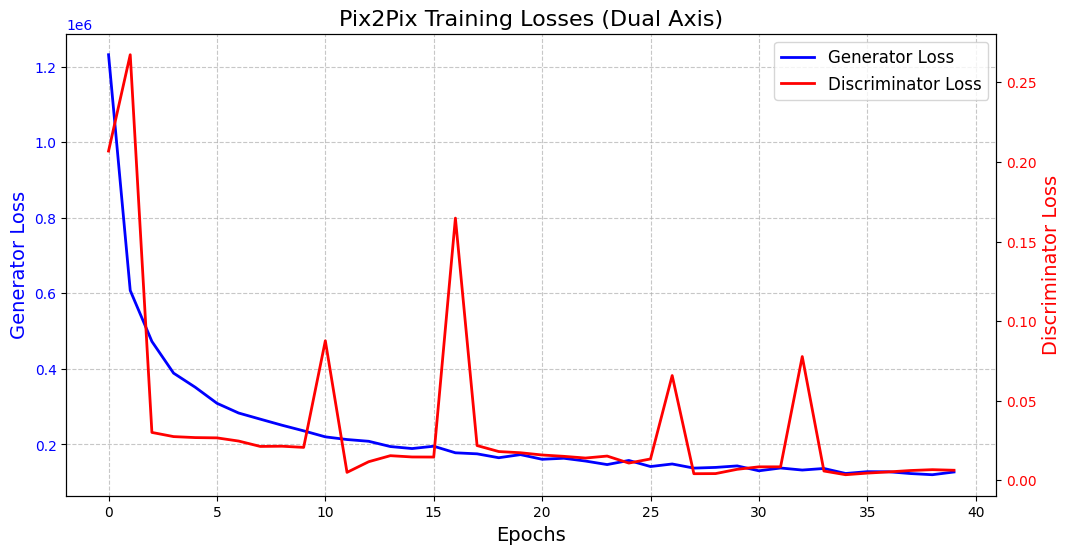

In [11]:
# ================================ MINOR TWEAK WITHIN the  TRAINING LOOP ================================

# @tf.function
# def train_step(input_image, target, epoch):
#     with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
#         gen_output = generator(input_image, training=True)

#         disc_real_output = discriminator([input_image, target], training=True)
#         disc_generated_output = discriminator([input_image, gen_output], training=True)

#         # UPDATED: Added input_image at the end here so loss block can extract the mask
#         gen_total_loss = generator_loss(disc_generated_output, gen_output, target, input_image)
#         disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

#     generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
#     discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

#     generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
#     discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))




# def fit(train_ds, epochs):
#     for epoch in range(epochs):
#         print(f"Epoch {epoch+1}/{epochs}")
#         for n, (input_image, target) in train_ds.enumerate():
#             train_step(input_image, target, epoch)
#             if n % 50 == 0:
#                 print(f"Batch {n} processed")

# # Start training (Start with 50 epochs for Version 1)
# EPOCHS = 20
# fit(train_ds, EPOCHS)

# ================================  TWEAK WITHIN the  TRAINING LOOP ================================

import matplotlib.pyplot as plt
import os

# --- 1. Modify train_step to RETURN the losses ---
@tf.function
def train_step(input_image, target, epoch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_output = generator(input_image, training=True)

        disc_real_output = discriminator([input_image, target], training=True)
        disc_generated_output = discriminator([input_image, gen_output], training=True)

        # Calculate losses
        # Added input_image at the end here so loss block can extract the mask
        gen_total_loss = generator_loss(disc_generated_output, gen_output, target, input_image)
        disc_loss = discriminator_loss(disc_real_output, disc_generated_output)

    generator_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    discriminator_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(generator_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_variables))
    
    # NEW: Return the loss values so the fit loop can track them
    return gen_total_loss, disc_loss

# --- 2. Update the fit function to track and average losses ---
def fit(train_ds, epochs):
    # Initialize lists to store the average loss per epoch
    history = {'gen_loss': [], 'disc_loss': []}
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        
        # Trackers for the current epoch
        epoch_gen_loss = 0.0
        epoch_disc_loss = 0.0
        num_batches = 0
        
        for n, (input_image, target) in train_ds.enumerate():
            # Catch the returned losses
            g_loss, d_loss = train_step(input_image, target, epoch)
            
            # Accumulate them
            epoch_gen_loss += g_loss
            epoch_disc_loss += d_loss
            num_batches += 1
            
            if n % 50 == 0:
                print(f"Batch {n} processed - Gen Loss: {g_loss:.4f}, Disc Loss: {d_loss:.4f}")
        
        # Calculate the average loss for this entire epoch
        avg_gen_loss = (epoch_gen_loss / num_batches).numpy()
        avg_disc_loss = (epoch_disc_loss / num_batches).numpy()
        
        # Save to history list
        history['gen_loss'].append(avg_gen_loss)
        history['disc_loss'].append(avg_disc_loss)
        
        print(f"Epoch {epoch+1} Finished -> Avg Gen Loss: {avg_gen_loss:.4f} | Avg Disc Loss: {avg_disc_loss:.4f}")
        
    # NEW: Once all epochs are done, plot the results
    plot_training_history(history)


# --- 3. Add the plotting function ---
# ===============================  visualization with dual axis for better clarity  ===========================================
def plot_training_history(history):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Plot Generator Loss on the Left Y-Axis
    color = 'blue'
    ax1.set_xlabel('Epochs', fontsize=14)
    ax1.set_ylabel('Generator Loss', color=color, fontsize=14)
    line1 = ax1.plot(history['gen_loss'], label='Generator Loss', color=color, linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Create a secondary Y-Axis for the Discriminator
    ax2 = ax1.twinx()  
    color = 'red'
    ax2.set_ylabel('Discriminator Loss', color=color, fontsize=14)
    line2 = ax2.plot(history['disc_loss'], label='Discriminator Loss', color=color, linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, fontsize=12, loc='upper right')
    
    plt.title('Pix2Pix Training Losses (Dual Axis)', fontsize=16)
    
    save_path = '/kaggle/working/training_loss_chart.png'
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    print(f"\nLoss chart successfully saved to: {save_path}")
    
    plt.show()
    plt.close()

# Start training
EPOCHS = 40
fit(train_ds, EPOCHS)

# Step 5: Evaluating the Model (Metrics)

In [12]:
def evaluate_model(test_dataset, generator):
    print("Evaluating model on the test set...")
    
    total_mae = 0.0
    total_ssim = 0.0
    total_psnr = 0.0
    num_batches = 0
    
    for input_image, target in test_dataset:
        # Generate faces (training=False ensures batch norm behaves correctly for inference)
        generated_images = generator(input_image, training=False)
        
        # Calculate MAE
        mae = tf.reduce_mean(tf.abs(target - generated_images))
        total_mae += mae.numpy()
        
        # Calculate SSIM and PSNR
        # SSIM and PSNR expect images in the range [0, 255] or [0, 1]. 
        # Our images are currently [-1, 1], so we shift them to [0, 1] first.
        target_norm = (target + 1.0) / 2.0
        generated_norm = (generated_images + 1.0) / 2.0
        
        ssim = tf.image.ssim(target_norm, generated_norm, max_val=1.0)
        total_ssim += tf.reduce_mean(ssim).numpy()
        
        psnr = tf.image.psnr(target_norm, generated_norm, max_val=1.0)
        total_psnr += tf.reduce_mean(psnr).numpy()
        
        num_batches += 1
        
    avg_mae = total_mae / num_batches
    avg_ssim = total_ssim / num_batches
    avg_psnr = total_psnr / num_batches
    
    print("-" * 30)
    print(f"Test MAE:  {avg_mae:.4f} (Closer to 0 is better)")
    print(f"Test SSIM: {avg_ssim:.4f} (Closer to 1 is better)")
    print(f"Test PSNR: {avg_psnr:.4f} dB (Higher is better)")
    print("-" * 30)

# Run the evaluation
evaluate_model(test_ds, generator)

Evaluating model on the test set...
------------------------------
Test MAE:  0.1786 (Closer to 0 is better)
Test SSIM: 0.4030 (Closer to 1 is better)
Test PSNR: 17.6179 dB (Higher is better)
------------------------------


# Step 6 Model saving

In [13]:
import os

output_dir = '/kaggle/working/'

# ================ OLD SAVING METHOD  ================
# model_name = 'MFSR_model_v5.keras'
# save_path = os.path.join(output_dir, model_name)
# print("Saving the Generator model...")
# generator.save(save_path)
# print(f"Model successfully saved to: {save_path}")

# ================ NEW SAVING METHOD ================
gen_model_name = 'MFSR_generator_v5.keras'
disc_model_name = 'MFSR_discriminator_v5.keras'

# 1. Save the Generator
gen_save_path = os.path.join(output_dir, gen_model_name)
generator.save(gen_save_path)
print(f"Generator saved to: {gen_save_path}")

# 2. Save the Discriminator
disc_save_path = os.path.join(output_dir, disc_model_name)
discriminator.save(disc_save_path)
print(f"Discriminator saved to: {disc_save_path}")

Generator saved to: /kaggle/working/MFSR_generator_v5.keras
Discriminator saved to: /kaggle/working/MFSR_discriminator_v5.keras


# Step 8: Inference and Visualization

> ## model loading (keras format):

In [14]:
import os
import tensorflow as tf

# Define the exact path where your models are saved
model_dir = '/kaggle/working/'
gen_model_name = 'MFSR_generator_v5.keras'
disc_model_name = 'MFSR_discriminator_v5.keras'

gen_load_path = os.path.join(model_dir, gen_model_name)
disc_load_path = os.path.join(model_dir, disc_model_name)

print(f"Loading the Generator model from: {gen_load_path} ...")
# Load the models with compile=False for inference
loaded_generator = tf.keras.models.load_model(gen_load_path, compile=False)

print(f"Loading the Discriminator model from: {disc_load_path} ...")
loaded_discriminator = tf.keras.models.load_model(disc_load_path, compile=False)

print("Models successfully loaded and ready for inference!")

# Optional: Print the model summary just to verify the architecture loaded correctly
# loaded_generator.summary()
# loaded_discriminator.summary()

Loading the Generator model from: /kaggle/working/MFSR_generator_v5.keras ...
Loading the Discriminator model from: /kaggle/working/MFSR_discriminator_v5.keras ...
Models successfully loaded and ready for inference!


> ## Inference

Running inference on a test sample...


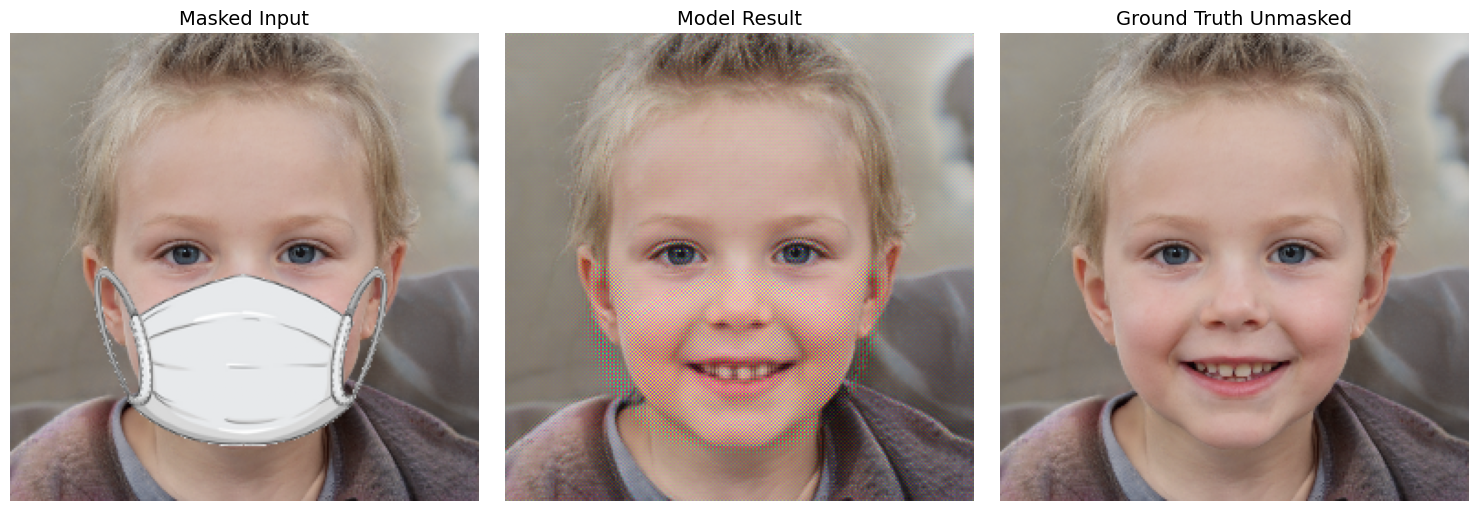

Model successfully saved to: /kaggle/working/inference_image0.png


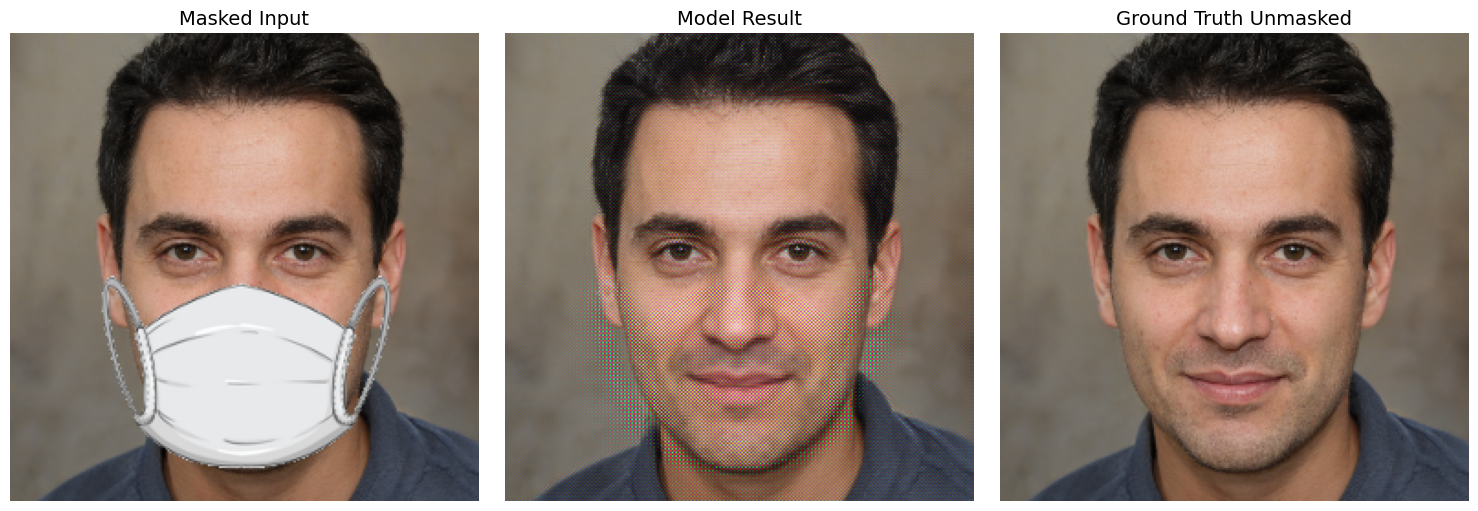

Model successfully saved to: /kaggle/working/inference_image0.png


In [15]:
import os
import matplotlib.pyplot as plt

# Define the precise static Kaggle output path from your snippet
output_dir = '/kaggle/working/'
save_name = 'inference_image0.png'  # Added extension explicitly for matplotlib
save_path = os.path.join(output_dir, save_name)

def generate_and_plot_images(model, test_input, target, save_path=None):
    # Generate the unmasked face
    prediction = model(test_input, training=False)
    
    # Take the first image in the batch (index 0)
    display_list = [test_input[0], prediction[0], target[0]]
    titles = ['Masked Input', 'Model Result', 'Ground Truth Unmasked']
    
    plt.figure(figsize=(15, 5))
    
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.title(titles[i], fontsize=14)
        
        # Denormalize the image from [-1, 1] to [0, 1] for matplotlib
        img = display_list[i] * 0.5 + 0.5
        
        plt.imshow(img)
        plt.axis('off')
        
    plt.tight_layout()

    plt.show()
    
    # MODIFICATION: Saves to the exact path specified, overwriting it if it already exists
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Model successfully saved to: {save_path}")
        
        
    plt.close() # Free up memory inside the Kaggle environment

# Extract a single batch from the test dataset and visualize it
print("Running inference on a test sample...")
for example_input, example_target in test_ds.take(2):
    # Pass the exact same static save_path every time
    generate_and_plot_images(generator, example_input, example_target, save_path=save_path)
 

> ## New inference

In [16]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Define the precise static Kaggle output path from your snippet
output_dir = '/kaggle/working/'
save_name = 'inference_image.png' 
save_path = os.path.join(output_dir, save_name)

# UPGRADE: Added discriminator to the function parameters
def generate_and_plot_images(generator, discriminator, test_input, target, save_path=None, fig_title=None):
    # 1. Generate the unmasked face
    prediction = generator(test_input, training=False)
    
    # 2. Ask the discriminator to evaluate the GENERATED image
    # Note: PatchGAN takes [condition_image, target_image]
    disc_logits = discriminator([test_input, prediction], training=False)
    
    # 3. Convert raw logits to probabilities (0.0 = Fake, 1.0 = Real)
    heatmap_probs = tf.sigmoid(disc_logits[0]) 
    heatmap_2d = tf.squeeze(heatmap_probs) # Remove the channel dimension so it becomes a 30x30 2D array
    
    # Take the first image in the batch (index 0)
    display_list = [test_input[0], prediction[0], target[0]]
    titles = ['Masked Input', 'Model Result', 'Ground Truth', 'PatchGAN Heatmap\n(Red=Fake, Green=Real)']
    
    # Increased width from 15 to 20 to comfortably fit 4 subplots
    plt.figure(figsize=(20, 5))
    
    # Add a main title for the entire figure if provided
    if fig_title:
        plt.suptitle(fig_title, fontsize=18, fontweight='bold', y=1.05)
    
    # Plot the 3 standard images
    for i in range(3):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i], fontsize=14)
        
        # Denormalize the image from [-1, 1] to [0, 1] for matplotlib
        img = display_list[i] * 0.5 + 0.5
        
        plt.imshow(img)
        plt.axis('off')
        
    # Plot the 4th image: The Discriminator Heatmap
    plt.subplot(1, 4, 4)
    plt.title(titles[3], fontsize=14)
    # RdYlGn colormap forces 0 to be Red and 1 to be Green
    im = plt.imshow(heatmap_2d, cmap='RdYlGn', vmin=0, vmax=1)
    plt.axis('off')
    # Add a colorbar next to the heatmap to show the scale
    plt.colorbar(im, fraction=0.046, pad=0.04)
        
    plt.tight_layout()
    
    # Save the combined plot
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Model successfully saved to: {save_path}")
    else:
        plt.show()
        
    plt.close() # Free up memory inside the Kaggle environment

# Extract a single batch from the test dataset and visualize it
print("Running inference on a test sample...")
for example_input, example_target in test_ds.take(2):
    # Pass BOTH the generator and discriminator into the function, along with a title
    generate_and_plot_images(loaded_generator, loaded_discriminator, example_input, example_target, save_path=save_path, fig_title="MFSR Model v5 Inference")


Running inference on a test sample...
Model successfully saved to: /kaggle/working/inference_image.png
Model successfully saved to: /kaggle/working/inference_image.png


# **Project Documentation: MFSR model (Version 5)**

This notebook implements an **Image-to-Image Translation** model to reconstruct facial features hidden behind masks. 

##  Architecture Pivot
This Version 5 utilizes the **Pix2Pix (Conditional GAN)** architecture. This allows us to map a specific input image (masked) to a specific output image (unmasked).
* **Generator:** An upgraded **U-Net** architecture with skip connections to preserve spatial details. It uses bilinear `UpSampling2D` instead of standard transpose convolutions in the decoder layer to avoid overlapping checkerboard artifacts.
* **Discriminator:** A **PatchGAN** that evaluates pairs of images (Input + Target/Generated) to determine realism on a local patch level.

## Pipeline Steps Completed

1. **Data Ingestion & Preprocessing (`tf.data`)**
   * Configured paths to the Kaggle dataset mount points.
   * Solved filename mismatches using `tf.strings.regex_replace` to safely pair `with-mask-default-mask-seed.png` inputs with `seed.png` targets.
   * Standardized images to `256x256` and normalized pixels to the `[-1, 1]` range.
   * Implemented a reliable 80/20 Train/Test split via proper dataset shuffling before batching.

2. **Custom Training Loop**
   * Utilized `tf.GradientTape` for manual gradient application.
   * **Loss Functions:** Replaced standard Binary Crossentropy with **MSE (Least Squares GAN / LSGAN loss)** for improved stability and smoother generation. Combined this with **Weighted L1 Loss** (dynamically focuses more heavily inside the missing face region) and **Perceptual Loss** (uses a pre-trained VGG19 `block4_conv2` layer scaled by a factor of 10).
   * **Optimizer Tuning:** Since LSGAN fixes the vanishing gradient problem, the Discriminator's learning rate was restored to match the Generator (`2e-4` for both).
   * **Tracking:** Implemented history lists to record and plot metrics (Generator Loss vs. Discriminator Loss) with a dual-axis chart.

3. **Evaluation & Inference**
   * Integrated **MAE (Mean Absolute Error)**, **SSIM (Structural Similarity Index)**, and **PSNR (Peak Signal-to-Noise Ratio)** metrics to quantitatively evaluate the Generator on unseen test data.
   * Built custom inference visualization, denormalizing images from `[-1, 1]` back to `[0, 1]` to safely display the Input, Prediction, and Ground Truth side-by-side.

4. **Model Export**
   * Saved both the trained **Generator** (as `MFSR_generator_v5.keras`) and the **Discriminator** (as `MFSR_discriminator_v5.keras`) in the `/kaggle/working/` directory. This allows for both advanced inference (e.g., generating heatmaps) and easily resuming training in the future.

---
*End of Version 5 Pipeline.*

In [17]:
print ("version 5 done")

version 5 done
